In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams["font.sans-serif"] = "Arial"
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
import os
from os.path import dirname, join
import scanpy.external as sce
from matplotlib.pyplot import rc_context
import warnings
warnings.filterwarnings('ignore')

In [3]:
sc.settings.verbosity = 3 

In [4]:
sc.settings.set_figure_params(dpi=100, dpi_save=300,
                              facecolor='white', figsize=(4,4))

# clustering

In [5]:
adata = sc.read_h5ad('./data/RNA.merged.analysed.h5ad')

In [6]:
adata_raw = adata.raw.to_adata()

In [9]:
def preprocessing_step1(adata_tmp, n_top_genes=2000, genes_removed_from_HVG=None):
    '''
    preprocessing the adata of each major celltype
    '''
    sc.pp.highly_variable_genes(adata_tmp, n_top_genes=n_top_genes)
    if genes_removed_from_HVG:
        adata_tmp.var.loc[adata_tmp.var.index.isin(genes_removed_from_HVG), 'highly_variable']  = False
    adata_tmp.raw = adata_tmp
    adata_tmp = adata_tmp[:, adata_tmp.var.highly_variable]
    
    sc.pp.regress_out(adata_tmp, ['total_counts', 'pct_counts_mt'])  
        
    sc.pp.scale(adata_tmp, max_value=10)
    sc.tl.pca(adata_tmp, svd_solver='arpack')
    sc.pl.pca_variance_ratio(adata_tmp, log=True, n_pcs=50)
    return adata_tmp

def preprocessing_step2(adata_tmp, key, n_pcs, n_neighbors, sigma=0.1, lamb=1.0, theta=1.0):
    '''
    preprocessing the adata of each major celltype
    '''
    sce.pp.harmony_integrate(adata_tmp, key='sample', sigma=sigma, lamb=lamb, theta=theta)
    sc.pp.neighbors(adata_tmp, use_rep='X_pca_harmony', n_pcs=n_pcs, n_neighbors=n_neighbors)
    sc.tl.umap(adata_tmp)
    for i in [0.04,0.08,0.1,0.2, 0.3]:   
        sc.tl.leiden(adata_tmp, resolution=i, key_added=key+'_leiden_'+str(i)) 
    return adata_tmp

In [46]:
adata_fibro = adata_raw[adata_raw.obs.celltype.isin([ 'Fibroblast'])]  

In [47]:
adata_fibro.shape

(23966, 29584)

If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:19)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use
    finished (0:00:23)
computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:07)


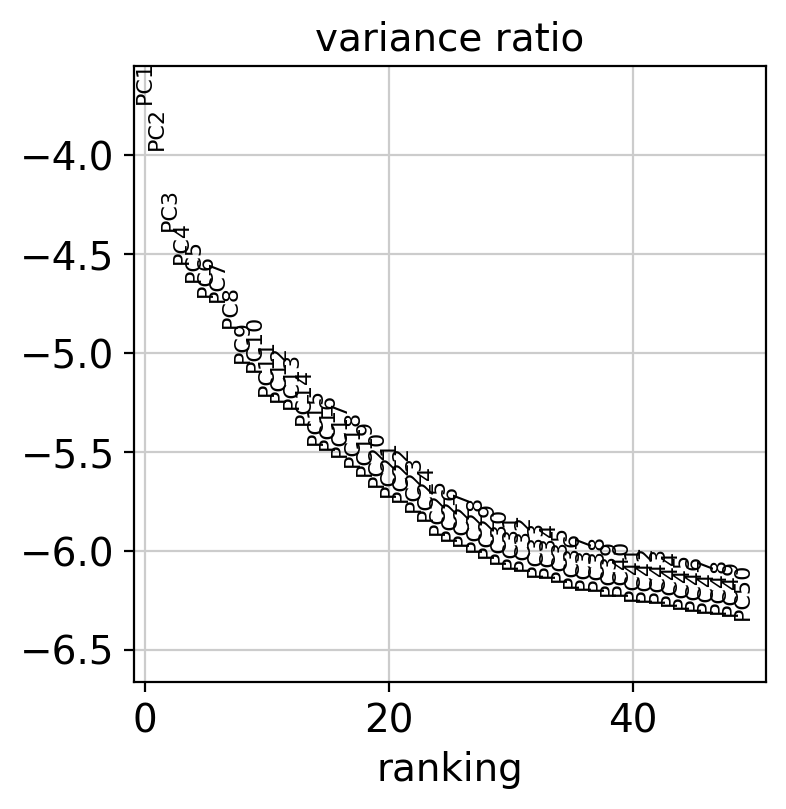

In [49]:
adata_fibro = preprocessing_step1(adata_fibro, n_top_genes=2000)

In [1]:
adata_fibro = preprocessing_step2(adata_fibro,  key='Fibro',  sigma=0.1, lamb=1.0, theta=0.3)

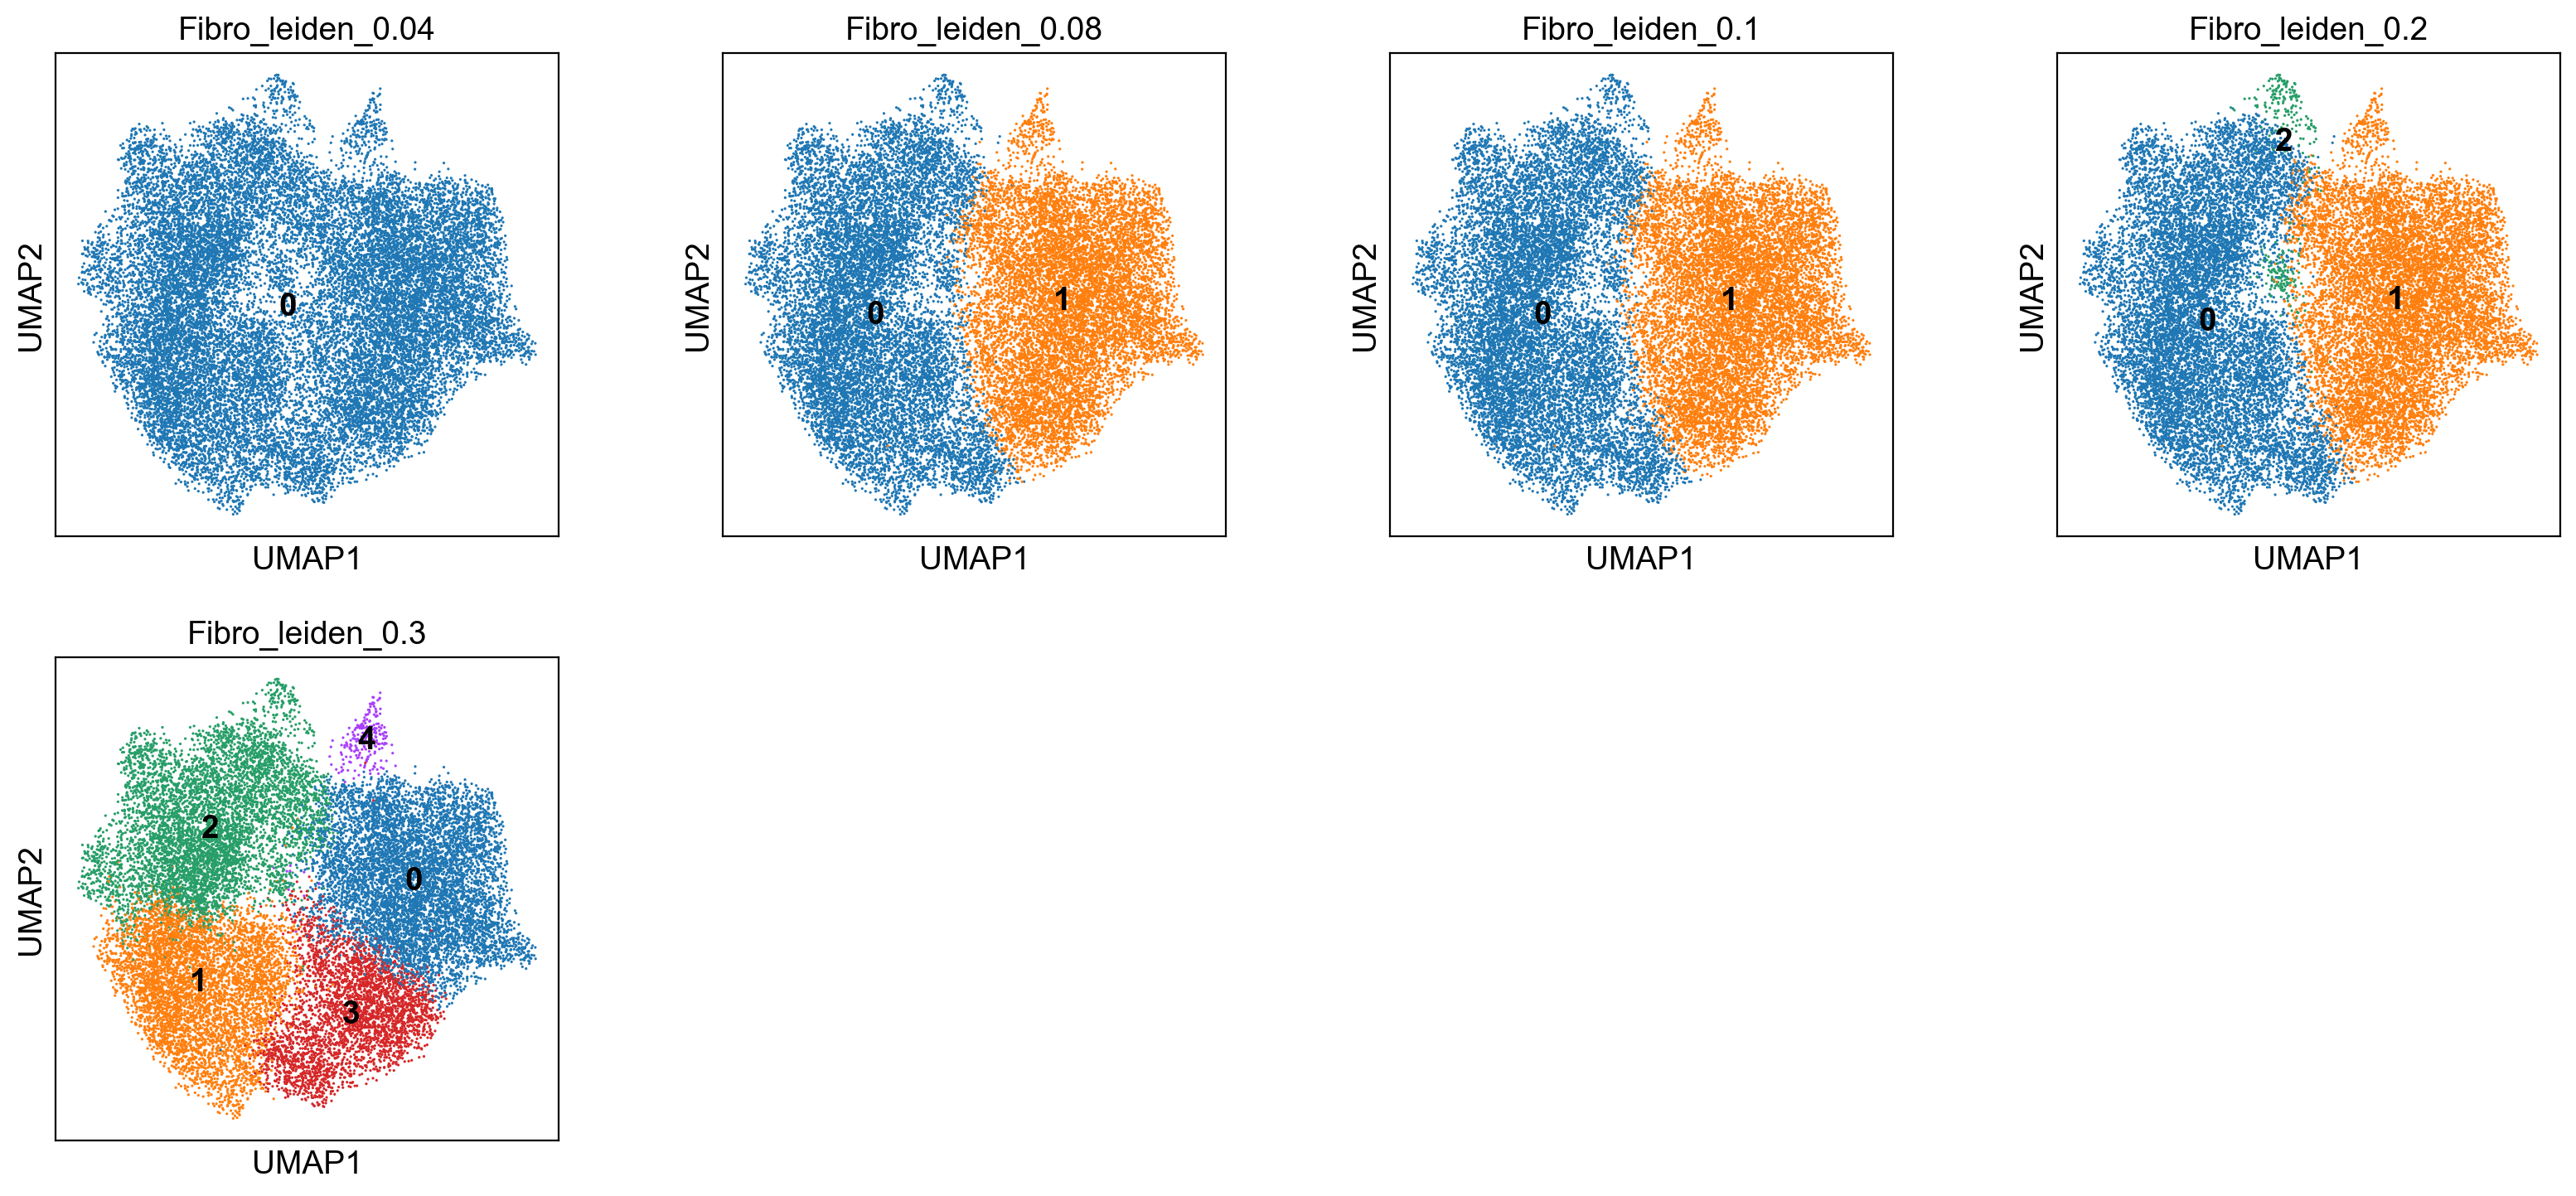

In [8]:
sc.pl.umap(adata_fibro, color=['Fibro_leiden_'+str(i) for i in [0.04,0.08,0.1,0.2, 0.3]],legend_loc='on data')

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:03)


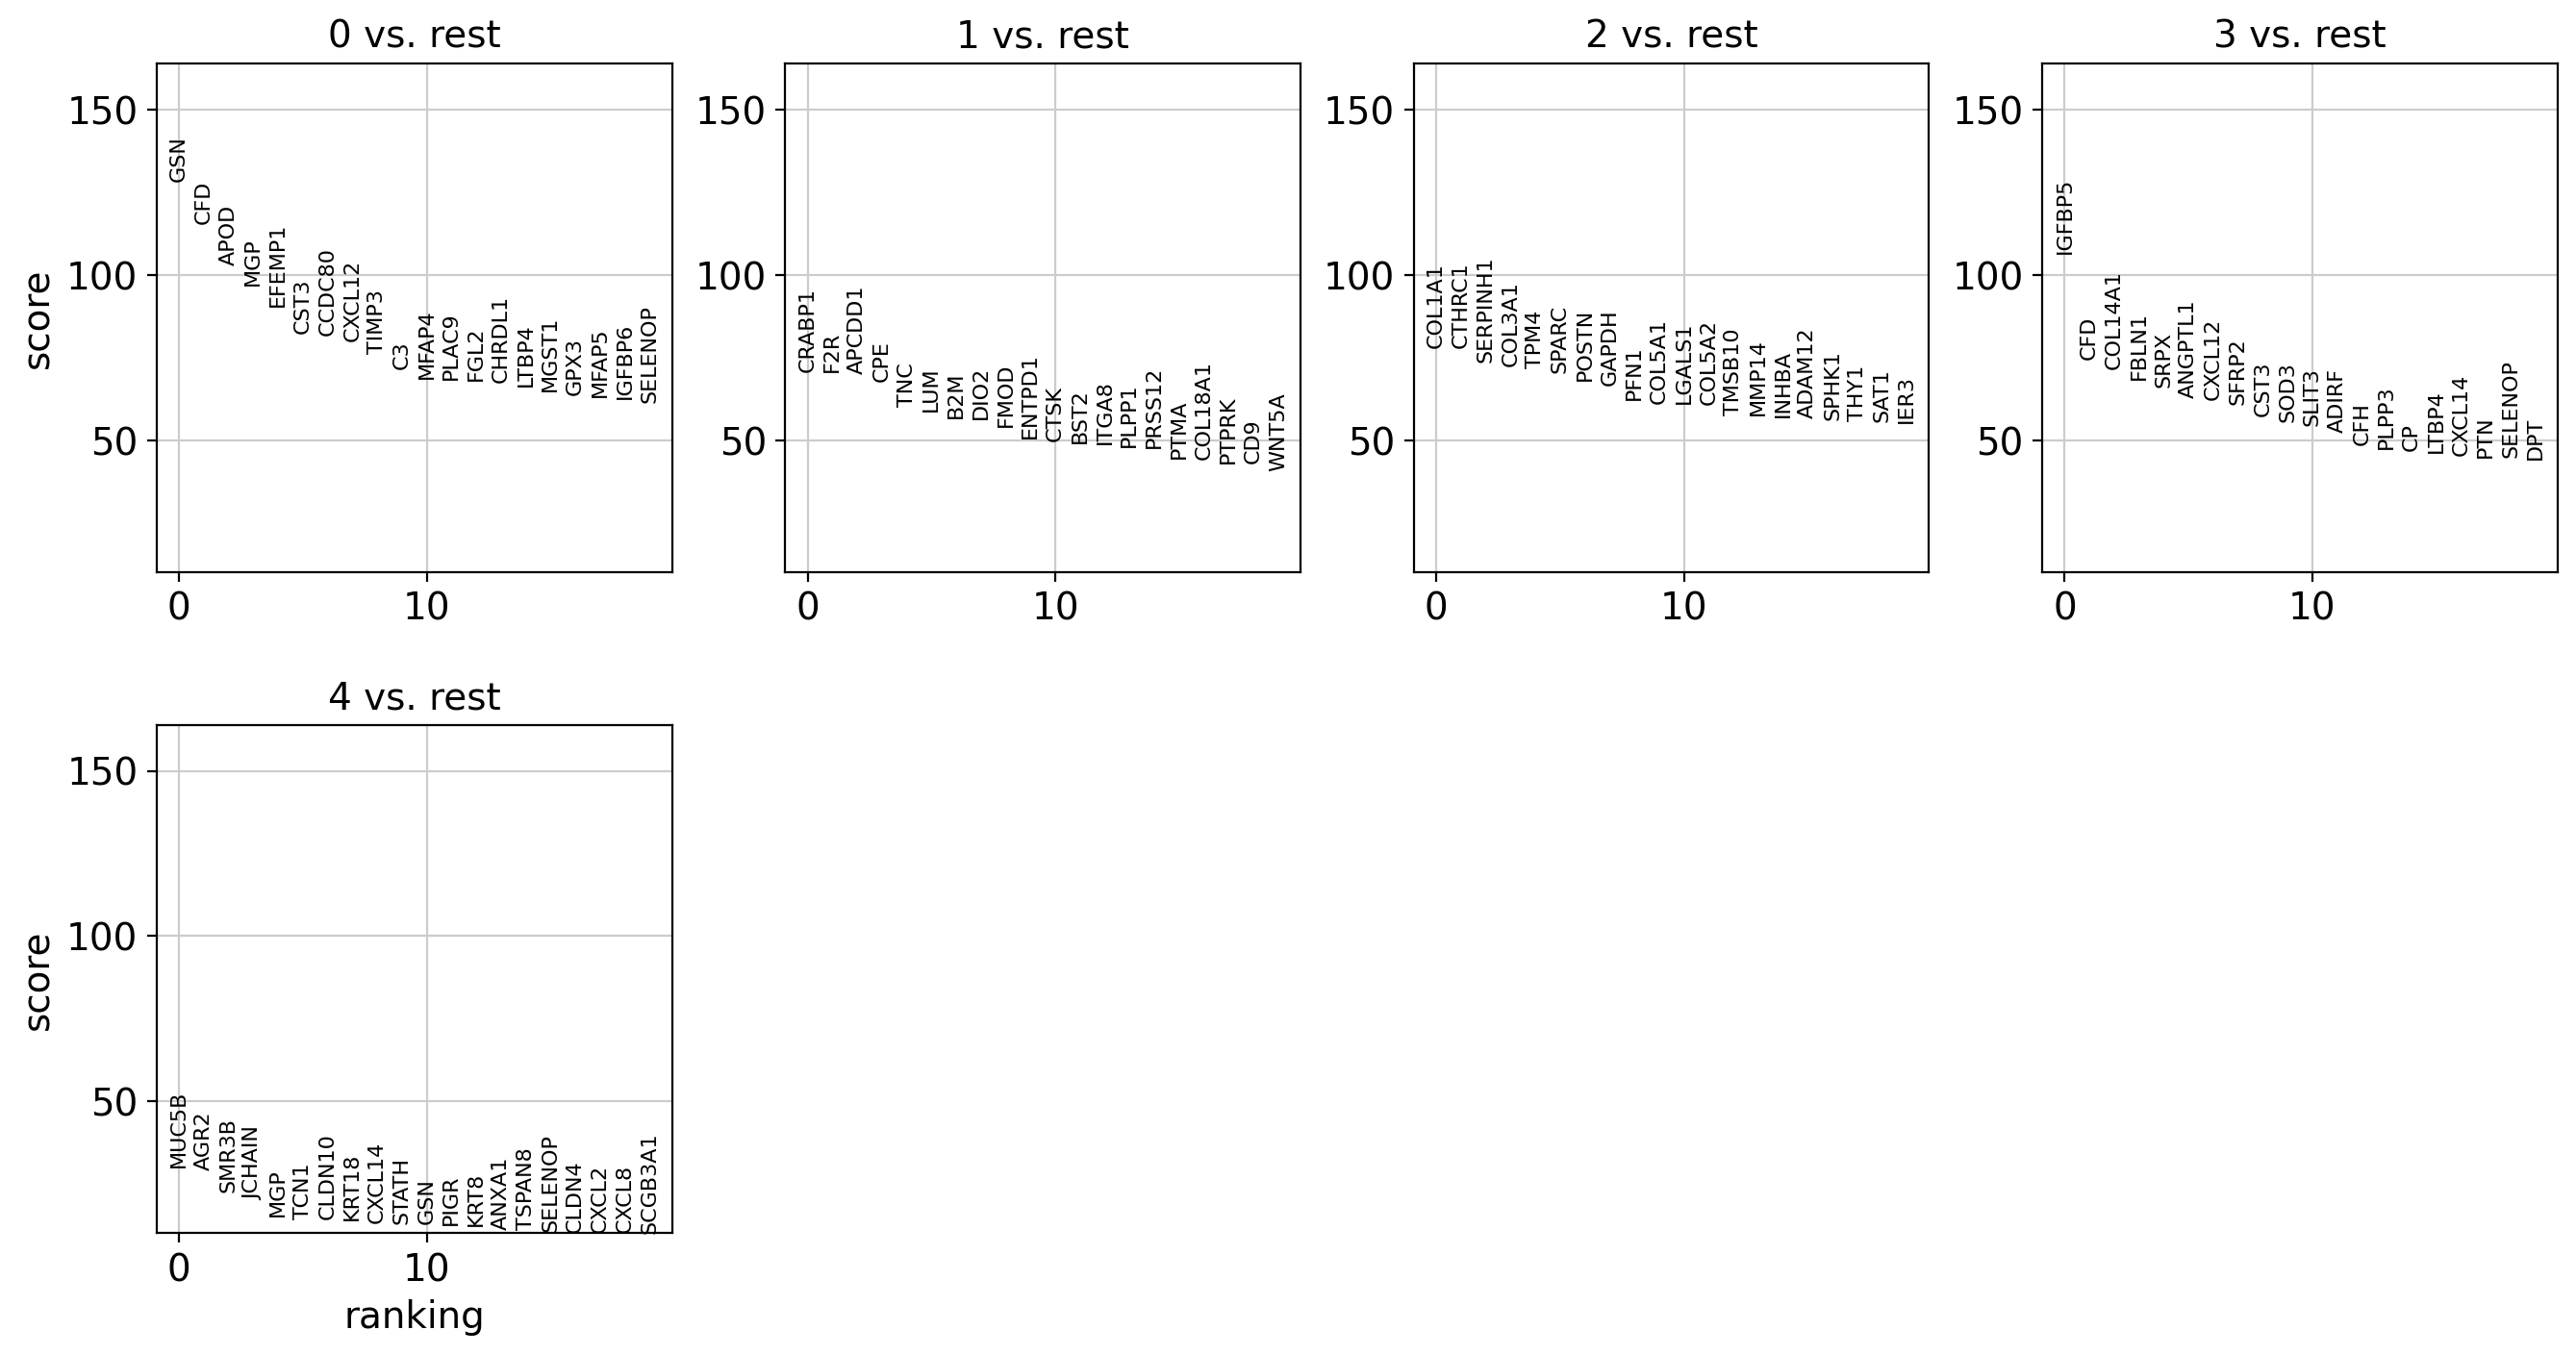

In [192]:
sc.tl.rank_genes_groups(adata_fibro, groupby='Fibro_leiden_0.3')
sc.pl.rank_genes_groups(adata_fibro, groups=None)

In [211]:
adata_fibro.obs['Fibro_celltype'] = adata_Fibro_partial.obs['Fibro_leiden_0.3'].map({'0':'CFD+ Fibro', '1':'CRABP1+ Fibro', '2':'Myofibroblast',  
                                                                                                    '3':'CFD+ Fibro', '4':'CFD+ Fibro'})  

In [215]:
adata_fibro.obs['Fibro_celltype'] = adata_fibro.obs['Fibro_celltype'].astype('category')
palette={'Myofibroblast':'#845EC2', 'CFD+ Fibro':'#00C9A7',  'CRABP1+ Fibro':'#F3C5FF'}
adata_fibro.uns['Fibro_celltype_colors'] = [palette[i] for i in adata_fibro.obs['Fibro_celltype'].cat.categories]

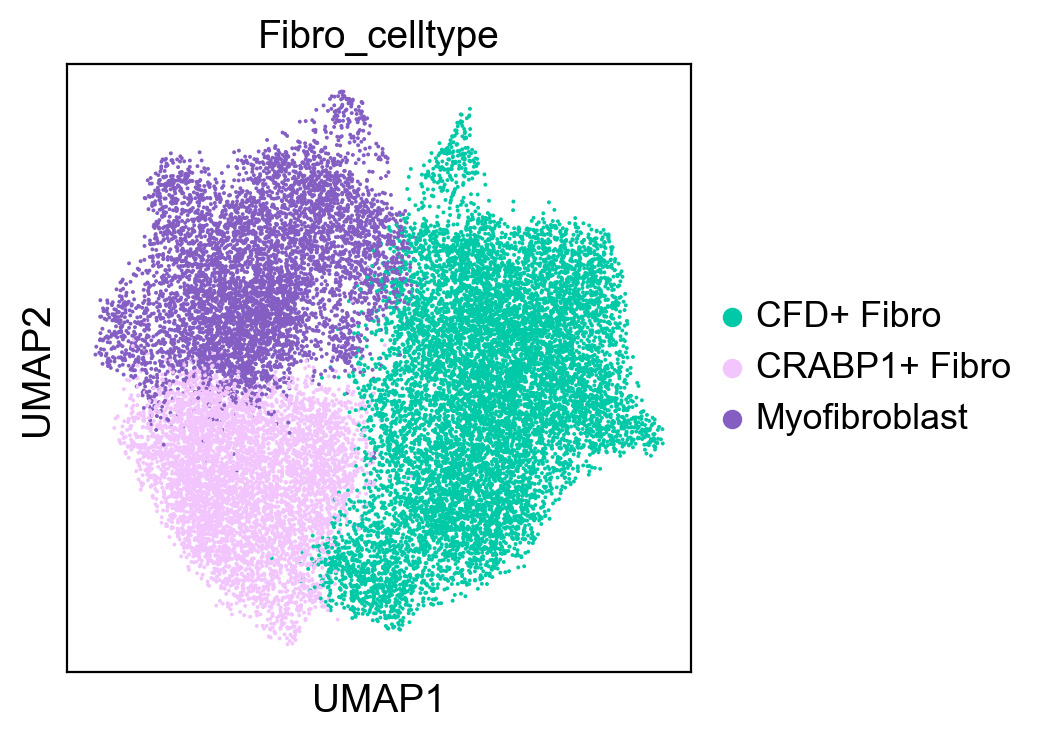

In [11]:
sc.pl.umap(adata_fibro, color=['Fibro_celltype'], size=8)

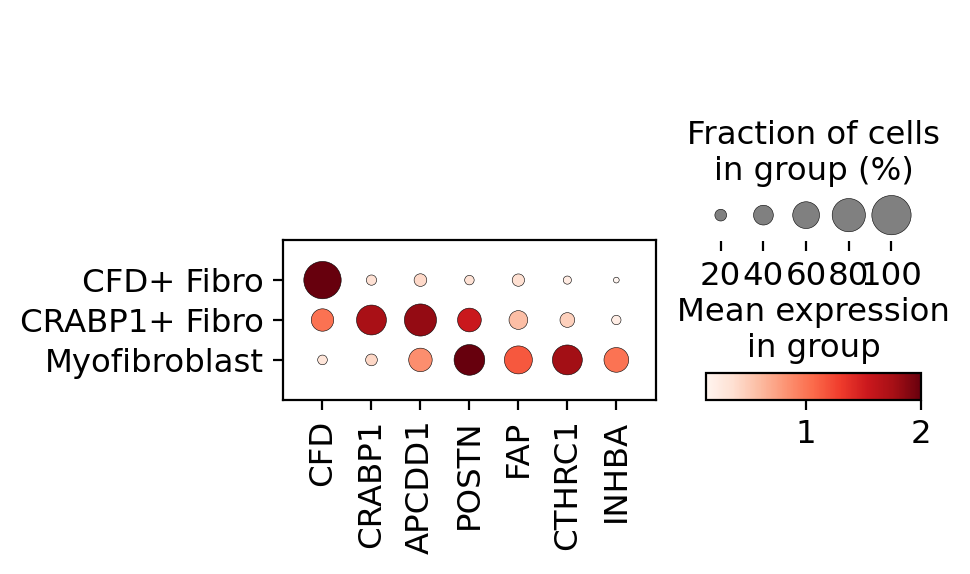

In [219]:
sc.pl.dotplot(adata_fibro, groupby='Fibro_celltype', var_names=['CFD', 'CRABP1', 'APCDD1' ,'POSTN', 'FAP', 'CTHRC1', 'INHBA'], vmax=2)

In [7]:
adata_fibro.write_h5ad('./data/adata_fibro.h5ad')

# plotting

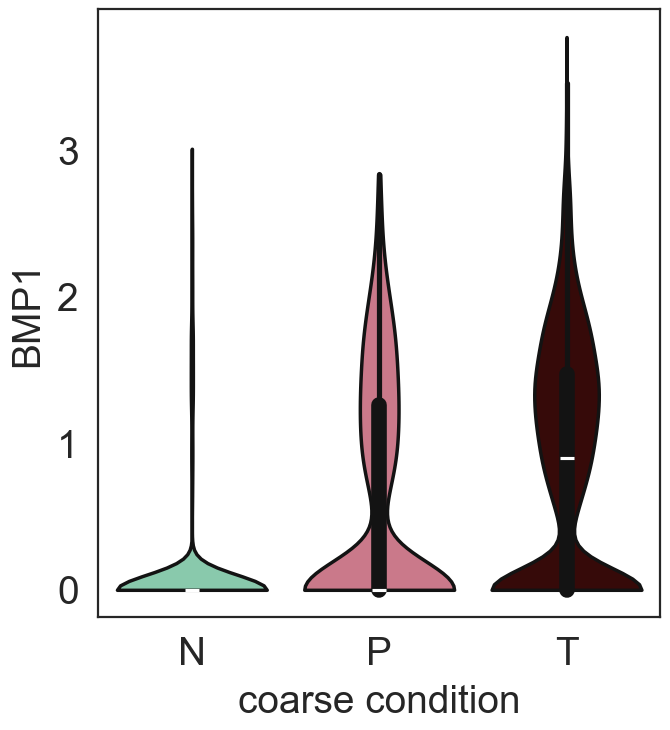

In [13]:
sc.pl.violin(adata_fibro[adata_fibro.obs['Fibro_celltype'] == 'Myofibroblast'], stripplot=False,
             groupby='coarse_condition',keys=['BMP1'], inner='box', save='_BMP1_expression_cross_stages.pdf'
            )

In [16]:
adata_fibro = adata_fibro.raw.to_adata()

In [18]:
df = adata_fibro[adata_fibro.obs['Fibro_celltype'] == 'Myofibroblast', ['BMP1']].to_df()
df['condition'] = adata_fibro.obs.loc[adata_fibro.obs['Fibro_celltype'] == 'Myofibroblast', 'coarse_condition']

In [23]:
df.groupby('condition')['BMP1'].mean()

condition
N    0.092411
P    0.597136
T    0.854517
Name: BMP1, dtype: float32

In [25]:
import scipy

In [26]:
scipy.stats.mannwhitneyu(df.loc[df['condition'] == 'N', 'BMP1'], df.loc[df['condition'] == 'P', 'BMP1'])
scipy.stats.mannwhitneyu(df.loc[df['condition'] == 'N', 'BMP1'], df.loc[df['condition'] == 'T', 'BMP1'])


MannwhitneyuResult(statistic=219727.5, pvalue=6.310187135333666e-64)

MannwhitneyuResult(statistic=798242.0, pvalue=1.9737078313088965e-150)

In [51]:
## feature gene to plot
gene_list = [
    "NCAM1", "FGF18", "C3", "PDGFD", "TNFSF13B", "CFD", "FGF2", "IGF1",
    "IGFBP5", "IL16", "TNFSF10", "ANGPTL1", "FGF14", "F10", "CFH", 
    "SERPING1",  "CXCL14",  "TNFSF12", "CXCL12", "C1S", "CCL21", "CRABP1", 
    "CCL19", "APCDD1", "CD86", "VTCN1", "THBS2", "LGALS9", "COL5A2", 
    "POSTN", "TGFB1", "COL27A1", "COL6A3", "COL4A2", "COL12A1", "COL4A1", 
    "COL3A1", "TGFBI", "ACTA2", "CTHRC1", "CD274", "COL11A1", "INHBA", 
    "BMP1", "COL5A3", "CD80", "CD276", "NID2", "FAP", "COL5A1", "PVR", 
    "COL1A1", "SPARC", "NECTIN2"
]

In [52]:
expr_df = adata_fibro[:,gene_list].to_df()

In [53]:
expr_df['Fibro_celltype'] = adata_fibro.obs['Fibro_celltype'].copy()

In [54]:
expr_df = expr_df.groupby('Fibro_celltype').mean()

In [25]:
sns.set_style('ticks')

<Figure size 3500x200 with 0 Axes>

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting legends..


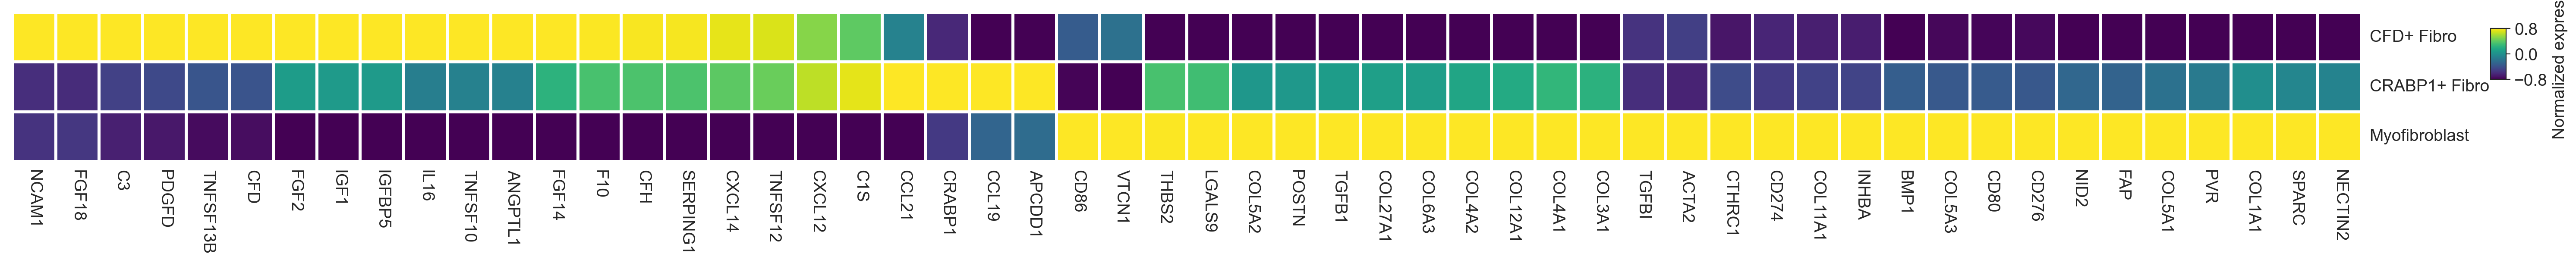

In [42]:
plt.figure(figsize=(35, 2))
cm2 = ClusterMapPlotter(data=expr_df, 
                       z_score=1,
                       vmax=0.8, vmin=-0.8, 
                       cmap='viridis',  
                       show_rownames=True, show_colnames=True,
                       row_cluster=False, col_cluster=False,  legend=True,
                        legend_width=2, linecolor='white',linewidths=2.5, label='Normalized expression')
plt.savefig('./Heatmap_Fibroblast_DEG.pdf', dpi=300, bbox_inches='tight')